# Topography EDA — Predicting Wildfire Size in the Western US
**Contributor: Chase Mayer (chase_mayer@berkeley.edu)**

This notebook (1) cleans the CAL FIRE incident dataset, (2) extracts topographic features (elevation, slope, aspect, hillshade) at each fire ignition point using USGS 3DEP via Google Earth Engine, and (3) performs EDA on the topographic features against the target (`incident_acres_burned`).

Run in Google Colab. Requires a Google Earth Engine account.

In [1]:
%pip install earthengine-api
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 1 — setup
import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ee.Authenticate()
ee.Initialize(project='topography-eda-ca-wildfires')  # <-- replace with your GEE cloud project


Successfully saved authorization token.


In [3]:
# Cell 2 — load and clean the CAL FIRE dataset
# Upload mapdataall.csv to the Colab session (or mount Drive) first.
df = pd.read_csv('mapdataall.csv')
n_raw = len(df)

df['created'] = pd.to_datetime(df['incident_dateonly_created'], errors='coerce')

# 1. Restrict to the modern record (2013+); pre-2013 entries are sparse and inconsistently reported
df = df[df['created'] >= '2013-01-01']
# 2. Drop non-fire incidents (CAL FIRE tracks floods/earthquakes in the same feed)
df = df[~df['incident_type'].isin(['Flood', 'Earthquake'])]
# 3. Target must be present and positive (log transform requires > 0)
df = df[df['incident_acres_burned'].notna() & (df['incident_acres_burned'] > 0)]
# 4. Coordinates must fall inside a California bounding box (a handful of records
#    have placeholder or out-of-state coordinates)
df = df[df['incident_latitude'].between(32.5, 42.1) &
        df['incident_longitude'].between(-124.6, -114.1)]
# 5. Keep only finalized incidents so the target is the *final* burned acreage
df = df[df['incident_is_final'] == 'Y']

df['log_acres'] = np.log10(df['incident_acres_burned'])
print(f'Rows: {n_raw} raw -> {len(df)} after cleaning')
df = df.reset_index(drop=True)

Rows: 3519 raw -> 3405 after cleaning


In [4]:
# Cell 3 — build the topography image (USGS 3DEP 10m) and terrain derivatives
dem = ee.Image('USGS/3DEP/10m')           # 1/3 arc-second (~10 m) elevation, CONUS
terrain = ee.Terrain.products(dem)         # adds slope, aspect, hillshade bands
topo = terrain.select(['elevation', 'slope', 'aspect', 'hillshade'])

# Local terrain context: std dev of elevation in a 1 km neighborhood = 'ruggedness'
ruggedness = dem.reduceNeighborhood(
    reducer=ee.Reducer.stdDev(),
    kernel=ee.Kernel.circle(radius=1000, units='meters')
).rename('elev_stddev_1km')
topo = topo.addBands(ruggedness)

/opt/miniconda3/envs/ml/lib/python3.12/site-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for USGS/3DEP/10m! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by USGS/3DEP/10m_collection

Learn more: https://developers.google.com/earth-engine/datasets/catalog/USGS_3DEP_10m

  warnings.warn(warning, category=DeprecationWarning)


In [6]:
test = sample_batch(df.iloc[:20])
print(test.head())
print(test[['elevation','slope','aspect','hillshade']].describe())

   aspect  elev_stddev_1km    elevation  hillshade  \
0      46        38.794834   342.111511        105   
1     193         0.869199  1119.069702        181   
2     158        65.433767  2408.295654        164   
3     205        65.651845   488.001465        205   
4     228        80.001147  1367.605713        210   

                            incident_id  slope  
0  2ca11d45-8139-4c16-8af0-880d99b21e82     36  
1  094719ba-a47b-4abb-9ec5-a506b2b9fd23      0  
2  58f89ff8-bd3e-4355-b1c0-8fa05c747d3f     14  
3  357ffc13-bef9-48eb-810f-c5de851972eb     19  
4  53122f0f-fefc-4dbf-b2d8-566b42ced66d     13  
         elevation      slope      aspect   hillshade
count    20.000000  20.000000   20.000000   20.000000
mean    778.535389  13.900000  166.600000  182.500000
std     774.719229  10.828325   83.048749   44.089025
min     -30.439886   0.000000    0.000000  103.000000
25%     232.957771   3.500000  106.250000  164.000000
50%     506.354645  14.000000  158.000000  179.500000
75%

In [7]:
# Cell 4 — sample topography at each ignition point (with progress + faster ruggedness)
topo_fine = terrain.select(['elevation', 'slope', 'aspect', 'hillshade'])  # 10 m
topo_rugged = ruggedness  # elev_stddev_1km, sampled coarser below

def sample_batch(batch_df):
    fc = ee.FeatureCollection([
        ee.Feature(ee.Geometry.Point([r.incident_longitude, r.incident_latitude]),
                   {'incident_id': r.incident_id})
        for r in batch_df.itertuples()
    ])
    fine = topo_fine.reduceRegions(collection=fc, reducer=ee.Reducer.first(), scale=10)
    both = topo_rugged.reduceRegions(collection=fine, reducer=ee.Reducer.first(), scale=30)
    out = both.getInfo()['features']
    return pd.DataFrame([f['properties'] for f in out])

BATCH = 500
parts = []
import time
for i in range(0, len(df), BATCH):
    t0 = time.time()
    parts.append(sample_batch(df.iloc[i:i+BATCH]))
    print(f'batch {i//BATCH + 1}/{(len(df)-1)//BATCH + 1} '
          f'({min(i+BATCH, len(df))}/{len(df)} pts) in {time.time()-t0:.0f}s')

topo_df = pd.concat(parts, ignore_index=True)
df = df.merge(topo_df, on='incident_id', how='left')
print('Missing topo values:', df['elevation'].isna().sum())
df.to_csv('fires_with_topography.csv', index=False)

batch 1/7 (500/3405 pts) in 266s
batch 2/7 (1000/3405 pts) in 302s
batch 3/7 (1500/3405 pts) in 199s
batch 4/7 (2000/3405 pts) in 442s
batch 5/7 (2500/3405 pts) in 341s
batch 6/7 (3000/3405 pts) in 325s
batch 7/7 (3405/3405 pts) in 339s
Missing topo values: 1


In [9]:
print([c for c in df.columns if 'elev' in c.lower() or 'std' in c.lower() or c == 'first'])
print(df.columns.tolist())

['elevation', 'first']
['incident_name', 'incident_is_final', 'incident_date_last_update', 'incident_date_created', 'incident_administrative_unit', 'incident_administrative_unit_url', 'incident_county', 'incident_location', 'incident_acres_burned', 'incident_containment', 'incident_control', 'incident_cooperating_agencies', 'incident_longitude', 'incident_latitude', 'incident_type', 'incident_id', 'incident_url', 'incident_date_extinguished', 'incident_dateonly_extinguished', 'incident_dateonly_created', 'is_active', 'calfire_incident', 'notification_desired', 'created', 'log_acres', 'aspect', 'elevation', 'first', 'hillshade', 'slope', 'aspect_sin', 'aspect_cos', 'south_facing']


In [10]:
df = df.rename(columns={'first': 'elev_stddev_1km'})

Note: `elev_stddev_1km` from `reduceNeighborhood` can be slow at 10 m scale. If batches time out, drop that band here and compute it separately with an `Export.table.toDrive` task, or sample it at `scale=30`.

In [11]:
# Cell 5 — feature engineering on aspect (circular variable)
# Aspect is in degrees [0, 360); encode as sin/cos so 359° and 1° are close,
# and add a south-facing indicator (drier fuels in the northern hemisphere).
df['aspect_sin'] = np.sin(np.radians(df['aspect']))
df['aspect_cos'] = np.cos(np.radians(df['aspect']))
df['south_facing'] = df['aspect'].between(112.5, 247.5).astype(int)

topo_features = ['elevation', 'slope', 'aspect_sin', 'aspect_cos',
                 'south_facing', 'hillshade', 'elev_stddev_1km']
df[topo_features + ['log_acres']].describe()

,elevation,slope,aspect_sin,aspect_cos,south_facing,hillshade,elev_stddev_1km,log_acres
count,3404.000000,3404.000000,3404.000000,3404.000000,3405.000000,3404.000000,3404.000000,3405.000000
mean,535.578499,9.704172,-0.030474,-0.078177,0.422320,181.131316,40.053253,2.044866
std,505.990922,10.334731,0.702439,0.706987,0.494002,29.514239,35.525119,0.883787
min,-64.950562,0.000000,-1.000000,-1.000000,0.000000,57.000000,0.238469,0.000000
25%,155.665771,2.000000,-0.719340,-0.766044,0.000000,173.000000,13.639519,1.397940
50%,389.904099,5.000000,-0.052336,-0.173648,0.000000,180.000000,31.052940,1.838849
75%,751.542068,15.000000,0.669131,0.642788,1.000000,191.000000,56.383326,2.465383
max,3348.445068,53.000000,1.000000,1.000000,1.000000,255.000000,251.500373,6.013952


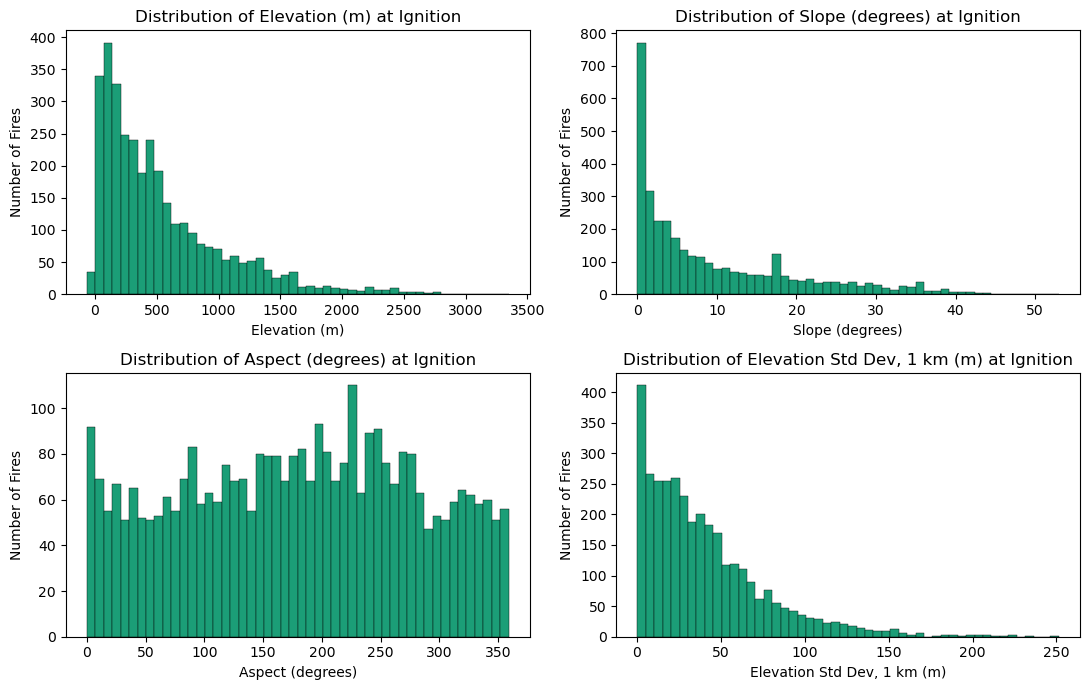

In [12]:
# Cell 6 — distributions of topographic features at ignition points
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col, label in zip(axes.ravel(),
                          ['elevation', 'slope', 'aspect', 'elev_stddev_1km'],
                          ['Elevation (m)', 'Slope (degrees)',
                           'Aspect (degrees)', 'Elevation Std Dev, 1 km (m)']):
    ax.hist(df[col].dropna(), bins=50, color='#1b9e77', edgecolor='k', lw=.3)
    ax.set_xlabel(label)
    ax.set_ylabel('Number of Fires')
    ax.set_title(f'Distribution of {label} at Ignition')
plt.tight_layout()
plt.savefig('topo_distributions.png', dpi=200)

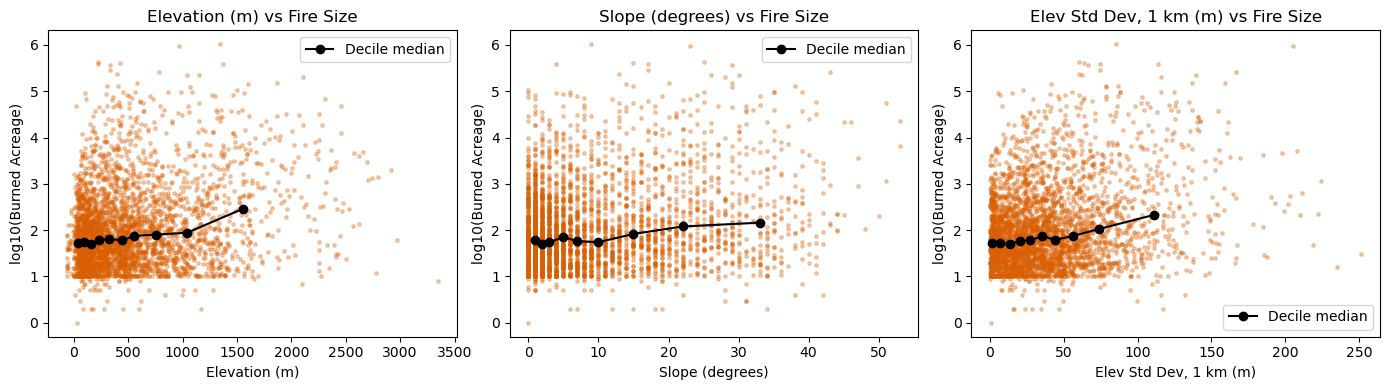

In [13]:
# Cell 7 — topography vs target
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes,
                          ['elevation', 'slope', 'elev_stddev_1km'],
                          ['Elevation (m)', 'Slope (degrees)', 'Elev Std Dev, 1 km (m)']):
    ax.scatter(df[col], df['log_acres'], s=6, alpha=.3, color='#d95f02')
    # binned median to expose the trend through the noise
    bins = pd.qcut(df[col], 10, duplicates='drop')
    med = df.groupby(bins, observed=True).agg(x=(col, 'median'), y=('log_acres', 'median'))
    ax.plot(med['x'], med['y'], 'o-', color='black', label='Decile median')
    ax.set_xlabel(label)
    ax.set_ylabel('log10(Burned Acreage)')
    ax.set_title(f'{label} vs Fire Size')
    ax.legend()
plt.tight_layout()
plt.savefig('topo_vs_target.png', dpi=200)

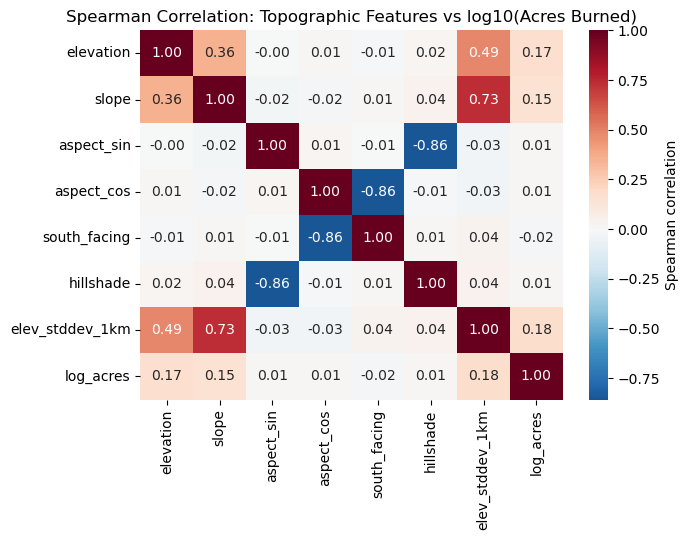

In [14]:
# Cell 8 — correlation heatmap (Spearman: robust to the skewed target)
corr = df[topo_features + ['log_acres']].corr(method='spearman')
plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Spearman correlation'})
plt.title('Spearman Correlation: Topographic Features vs log10(Acres Burned)')
plt.tight_layout()
plt.savefig('topo_correlation_heatmap.png', dpi=200)

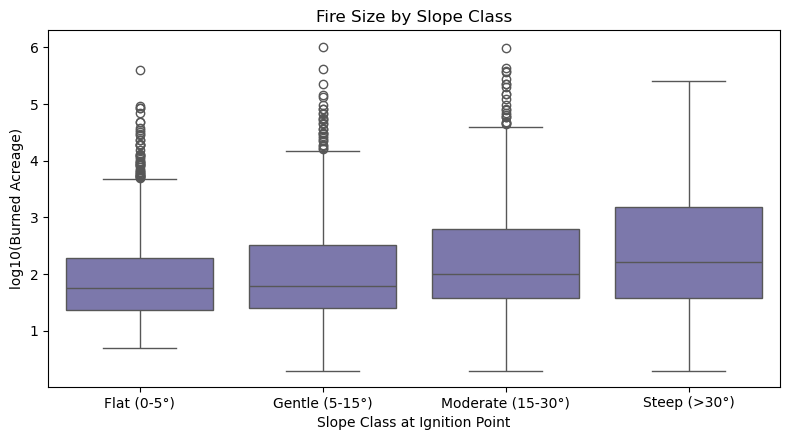

In [15]:
# Cell 9 — boxplot of fire size by terrain class
df['slope_class'] = pd.cut(df['slope'], [0, 5, 15, 30, 90],
                           labels=['Flat (0-5°)', 'Gentle (5-15°)',
                                   'Moderate (15-30°)', 'Steep (>30°)'])
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x='slope_class', y='log_acres', color='#7570b3')
plt.xlabel('Slope Class at Ignition Point')
plt.ylabel('log10(Burned Acreage)')
plt.title('Fire Size by Slope Class')
plt.tight_layout()
plt.savefig('topo_slope_boxplot.png', dpi=200)

In [16]:
# Cell 10 — train/validation/test split (chronological, to avoid leakage)
# Final-year fires held out as test; split sizes reported for the milestone writeup.
df_sorted = df.sort_values('created')
n = len(df_sorted)
train = df_sorted.iloc[:int(.7*n)]
val   = df_sorted.iloc[int(.7*n):int(.85*n)]
test  = df_sorted.iloc[int(.85*n):]
print(f'train={len(train)}  val={len(val)}  test={len(test)}')
print('train dates:', train.created.min().date(), '->', train.created.max().date())
print('test dates :', test.created.min().date(), '->', test.created.max().date())

train=2383  val=511  test=511
train dates: 2013-02-24 -> 2024-07-12
test dates : 2025-06-17 -> 2026-06-09
